In [1]:
import time
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji, re, string

import nltk
from nltk.corpus import stopwords
import spacy

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

import warnings
warnings.filterwarnings("ignore")



d:\Arquivos_Acer\Documents\UFC\PrejudicePT-br-main\ambiente_prejudice\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../../Datasets/Correto_whatsapp_rotulado_revisado.csv')
df.head()

,text_content_anonymous,preconceito
0,Show :clapping_hands_light_skin_tone::clapping...,0
1,Mais uma vez o PT= Partido das Trevas apela ao...,1
2,Se não puder avise só para não quebrar a vigíl...,0
3,E a esquerda tenta impedir o trabalho,0
4,Deus perdoa porque eles Não sabem que fazem e ...,0


In [3]:
df.shape

(3000, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   text_content_anonymous  2999 non-null   object
 1   preconceito             3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [5]:
mensagens_coluna = 'text_content_anonymous'  
df[mensagens_coluna] = df[mensagens_coluna].astype(str) # garantindo que todos os valores são strings

# Tokenizar mensagens (simples divisão por espaços)
df['num_tokens'] = df[mensagens_coluna].apply(lambda x: len(x.split()))

## Processamento do texto

In [6]:
unicode_emoji = {}
for key, value in emoji.EMOJI_DATA.items():
    try:
        unicode_emoji[key] = value['pt']
    except:
        pass

#emojis and punctuation
emojis_list = list(unicode_emoji)
punct = list(string.punctuation)
emojis_punct = emojis_list + punct

def processEmojisPunctuation(text, remove_punct = True):
    '''
    Put spaces between emojis. Removes punctuation.
    '''
    #get all unique chars
    chars = set(text)
    #for each unique char in text, do:
    for c in chars:
        #remove punctuation
        if remove_punct:
            if c in emojis_list:
                text = text.replace(c, ' ' + c + ' ')
            if c in punct:
                text = text.replace(c, ' ')

        #put spaces between punctuation
        else:
            if c in emojis_punct:
                text = text.replace(c, ' ' + c + ' ')          

    text = text.replace('  ', ' ')
    return text

#stop words removal
stop_words = list(stopwords.words('portuguese'))
new_stopwords = ['aí','pra','vão','vou','onde','lá','aqui',
                 'tá','pode','pois','so','deu','agora','todo',
                 'nao','ja','vc', 'bom', 'ai','kkk','kkkk','ta', 'voce', 'alguem', 'ne', 'pq',
                 'cara','to','mim','la','vcs','tbm', 'tudo']
stop_words = stop_words + new_stopwords
final_stop_words = []
for sw in stop_words:
    sw = ' '+ sw + ' '
    final_stop_words.append(sw)

def removeStopwords(text):
    for sw in final_stop_words:
        text = text.replace(sw,' ')
    text = text.replace('  ',' ')
    return text

#lemmatization
nlp = spacy.load('pt_core_news_sm')
def lemmatization(text):
    doc = nlp(text)
    for token in doc:
        if token.text != token.lemma_:
            text = text.replace(token.text, token.lemma_)
    return text


def domainUrl(text):
    '''
    Substitutes an URL in a text for the domain of this URL
    Input: an string
    Output: the string with the modified URL
    '''    
    if 'http' in text:
        re_url = '[^\s]*https*://[^\s]*'
        matches = re.findall(re_url, text, flags=re.IGNORECASE)
        for m in matches:
            domain = m.split('//')
            domain = domain[1].split('/')[0]
            text = re.sub(re_url, domain, text, 1)
        return text
    else:
        return text 

def preprocess(text):
    text = text.lower().strip()
    text = domainUrl(text)
    text = processEmojisPunctuation(text)
    text = removeStopwords(text)
    text = lemmatization(text)
    return text


## Carregar dicionário e contar categorias

In [7]:
def read_dic(filepath):
    """
    Reads a LIWC lexicon from a file in the .dic format, returning a tuple of
    (lexicon, category_names), where:
    * `lexicon` is a dict mapping string patterns to lists of category names
    * `category_names` is a list of category names (as strings)
    """
    with open(filepath, 'r', encoding='ISO-8859-1') as lines:
        # read up to first "%" (should be very first line of file)
        for line in lines:
            if line.strip() == "%":
                break
        category_names = []
        for line in lines:
            category_names.append(line.strip().split()[1])

    lexicon = {}
    for line in lines:
        pattern, *categories = line.strip().split()
        lexicon[pattern] = categories

    return lexicon, category_names


In [8]:
# Ter uma “tabela de consulta” para saber em qual categoria cada palavra cai.
def carregar_dicionario_personalizado(dic_path):
    categorias = {}
    lexicon = {}
    dentro_das_categorias = False
    
    with open(dic_path, 'r', encoding='utf-8') as file:
        for linha in file:
            linha = linha.strip()
            
            # Detecta a seção de categorias delimitada por '%'
            if linha == '%':
                dentro_das_categorias = not dentro_das_categorias
                continue
            
            # Lê as categorias personalizadas
            if dentro_das_categorias:
                codigo, categoria = linha.split()
                categorias[codigo] = categoria
            else:
                # Lê as palavras e suas categorias
                partes = linha.split("\t")
                palavra = partes[0]
                categoria_ids = partes[1:]
                lexicon[palavra] = [categorias[codigo] for codigo in categoria_ids if codigo in categorias]
    
    return lexicon, list(categorias.values())

# Caminho do arquivo .dic personalizado
dic_path = '../../Dicionário/v2_SocialLIWC_formatado_ordenado.dic'
lexicon, category_names = carregar_dicionario_personalizado(dic_path)

In [9]:
# Quebrar a frase em palavras para comparar com o dicionário.
def tokenize(text):
    tokens = []
    for match in re.finditer(r"\w+", text, re.UNICODE):
        tokens.append(match.group(0).lower())
    return tokens

In [10]:
df = df.reindex(columns=df.columns.tolist() + category_names)
df[category_names] = 0 

In [11]:
# Descobrir quais categorias estão presentes na frase.
def verificar_categorias(frase, lexicon):
    tokens = tokenize(frase)
    resultados = {categoria: 0 for categoria in category_names}
    
    for token in tokens:
        if token in lexicon:
            for categoria in lexicon[token]:
                resultados[categoria] = 1
    
    return resultados

In [12]:
lexicon, category_names = carregar_dicionario_personalizado(dic_path)
print("Lexicon carregado:", lexicon)
print("Categorias:", category_names)


Lexicon carregado: {'aberração': ['Capacitismo'], 'aberração*': ['Capacitismo'], 'aberrações': ['Capacitismo'], 'aleij*': ['Capacitismo'], 'aleija': ['Capacitismo'], 'aleijada': ['Capacitismo'], 'aleijadas': ['Capacitismo'], 'aleijadinha': ['Capacitismo'], 'aleijadinho': ['Capacitismo'], 'aleijado': ['Capacitismo'], 'aleijados': ['Capacitismo'], 'aleijai': ['Capacitismo'], 'analfabeto': ['Capacitismo', 'Xenofobia'], 'anormais': ['Capacitismo'], 'anormal': ['Capacitismo'], 'atrasada': ['Capacitismo', 'Xenofobia'], 'atrasadas': ['Capacitismo', 'Xenofobia'], 'atrasado': ['Capacitismo', 'Xenofobia'], 'atrasados': ['Capacitismo', 'Xenofobia'], 'autista': ['Capacitismo'], 'bobo': ['Capacitismo'], 'burro': ['Capacitismo'], 'burros': ['Capacitismo'], 'capenga': ['Capacitismo'], 'ceg*': ['Capacitismo'], 'cego': ['Capacitismo'], 'cegos': ['Capacitismo'], 'cegou': ['Capacitismo'], 'ceguei': ['Capacitismo'], 'cegueir*': ['Capacitismo'], 'cegueta': ['Capacitismo'], 'ceguinha': ['Capacitismo'], 'ceg

In [13]:
# Preencher o DataFrame com 0/1 indicando se a frase contém aquele tipo de preconceito.
# Aplica a verificação de categorias em cada frase do dataframe
for i, frase in df["text_content_anonymous"].items():
    resultados = verificar_categorias(frase, lexicon)
    for categoria, valor in resultados.items():
        df.at[i, categoria] = valor

# Exibe o DataFrame atualizado
df.head(25)

,text_content_anonymous,preconceito,num_tokens,Capacitismo,Gordofobia,Int.Religiosa,LGBTFobia,Misoginia,Xenofobia,Racismo,Hetarismo,Prec.Politico
0,Show :clapping_hands_light_skin_tone::clapping...,0,5,0,0,0,0,0,1,0,0,0
1,Mais uma vez o PT= Partido das Trevas apela ao...,1,43,0,0,0,0,0,0,0,0,0
2,Se não puder avise só para não quebrar a vigíl...,0,123,0,0,1,0,0,0,0,0,1
3,E a esquerda tenta impedir o trabalho,0,7,0,0,0,0,0,0,0,0,0
4,Deus perdoa porque eles Não sabem que fazem e ...,0,15,0,0,1,0,0,0,0,0,1
5,Abre o esgoto que vc chama de boca porra e adm...,1,17,0,0,1,0,1,0,0,0,1
6,A ditadura lulocomunista está na nossa porta. ...,1,53,0,0,0,0,0,0,0,0,1
7,:backhand_index_pointing_up: *Católicos do Bra...,1,29,0,0,0,0,0,0,0,0,0
8,Calma aí\nBasta reverter 3 milhões de votos\nT...,0,55,0,0,0,0,0,0,0,0,0
9,A gente pode manda em Deus ??? Ser ele tem um ...,0,27,1,0,1,0,0,0,0,0,1


Capacitismo       457
Gordofobia         43
Int.Religiosa    1002
LGBTFobia         118
Misoginia         251
Xenofobia         230
Racismo           260
Hetarismo          60
Prec.Politico    1536
dtype: int64


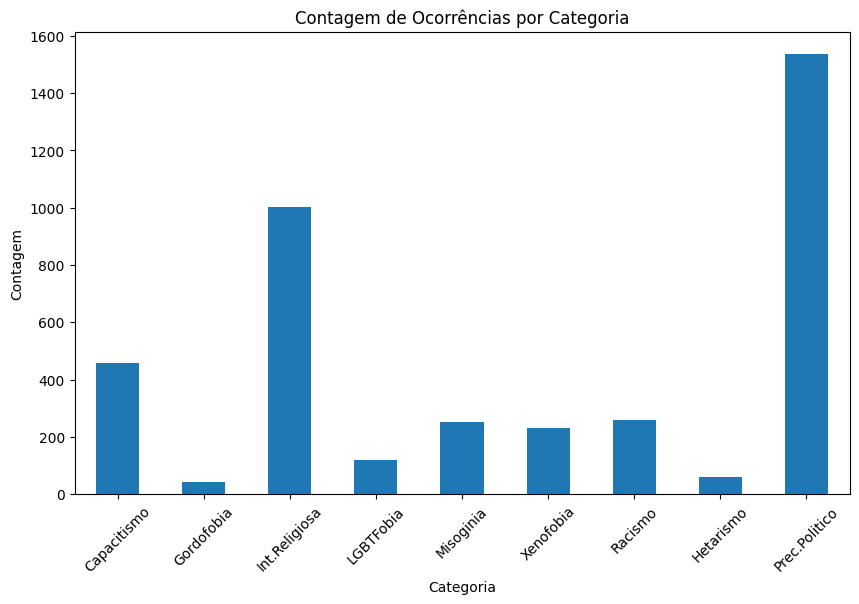

In [14]:
# Contagem de ocorrências de cada categoria
contagem_categorias = df[category_names].sum()

print(contagem_categorias)

# Passo 8: Plotagem do gráfico
plt.figure(figsize=(10, 6))
contagem_categorias.plot(kind='bar')
plt.title("Contagem de Ocorrências por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Contagem")
plt.xticks(rotation=45)
plt.show()

In [15]:
# === Renomeando colunas ===
# Agora sim, renomeia para usar no modelo
df = df.rename(columns={
    "text_content_anonymous": "text",
    "preconceito": "label"
})

df["label"] = df["label"].astype(int)


In [16]:
df.head()

,text,label,num_tokens,Capacitismo,Gordofobia,Int.Religiosa,LGBTFobia,Misoginia,Xenofobia,Racismo,Hetarismo,Prec.Politico
0,Show :clapping_hands_light_skin_tone::clapping...,0,5,0,0,0,0,0,1,0,0,0
1,Mais uma vez o PT= Partido das Trevas apela ao...,1,43,0,0,0,0,0,0,0,0,0
2,Se não puder avise só para não quebrar a vigíl...,0,123,0,0,1,0,0,0,0,0,1
3,E a esquerda tenta impedir o trabalho,0,7,0,0,0,0,0,0,0,0,0
4,Deus perdoa porque eles Não sabem que fazem e ...,0,15,0,0,1,0,0,0,0,0,1


In [17]:
# Função de pré-processamento
def preprocess_data(df, experiment):
    if 'processed' in experiment:
        print("Pré-processamento ativado.")
        pro_texts = [preprocess(t) for t in df['text']]
    else:
        print("Sem pré-processamento.")
        pro_texts = [processEmojisPunctuation(t.lower(), remove_punct=False) for t in df['text']]
    return pro_texts


In [18]:
classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "BernoulliNB": BernoulliNB(),
    "MultinomialNB": MultinomialNB(),  # cuidado: exige features não-negativas
    "LinearSVC": LinearSVC(dual="auto", max_iter=10000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SGDClassifier": SGDClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "MLP": MLPClassifier(max_iter=300)
}

In [19]:
# Selecionar as colunas das categorias e o rótulo
category_columns = [
    'Capacitismo', 'Gordofobia', 'Int.Religiosa', 'LGBTFobia',
    'Misoginia', 'Xenofobia', 'Racismo', 'Hetarismo', 'Prec.Politico'
]

## Modelos Pré treinados - Sem pré processamento

In [20]:
# === Pré-processamento dinâmico ===
df["text"] = preprocess_data(df, experiment="raw")  
df.head()

Sem pré-processamento.


,text,label,num_tokens,Capacitismo,Gordofobia,Int.Religiosa,LGBTFobia,Misoginia,Xenofobia,Racismo,Hetarismo,Prec.Politico
0,show : clapping _ hands _ light _ skin _ tone ...,0,5,0,0,0,0,0,1,0,0,0
1,mais uma vez o pt = partido das trevas apela a...,1,43,0,0,0,0,0,0,0,0,0
2,se não puder avise só para não quebrar a vigíl...,0,123,0,0,1,0,0,0,0,0,1
3,e a esquerda tenta impedir o trabalho,0,7,0,0,0,0,0,0,0,0,0
4,deus perdoa porque eles não sabem que fazem e ...,0,15,0,0,1,0,0,0,0,0,1


### melll-uff/bertweetbr

In [21]:

# === Configurações ===

model_name = "melll-uff/bertweetbr"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()

'''
def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls"):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]  # pega [CLS]
        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)  # média dos tokens
        else:
            raise ValueError("Pooling deve ser 'cls' ou 'mean'")

    return embeddings.cpu().numpy()
'''

texts = df["text"].tolist()
labels = df["label"].values

# Usar categorias do dicionário
X_categories = df[category_columns]
vocab_size_categories = X_categories.shape[1]

# Normalizar categorias 
scaler = StandardScaler()
X_categories_scaled = scaler.fit_transform(X_categories)


X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")

# Concatenar embeddings + categorias
X_full = np.hstack([X_embeddings, X_categories_scaled])
y = labels



skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_full, y):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Ajuste especial para MultinomialNB (precisa de entradas positivas)
        if clf_name == "MultinomialNB":
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_full.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])

# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size_combined"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time

print(results_df)
results_df.to_csv('./resultados/results_melll_uff_Sempre_processamento.csv', index=False)

Some weights of RobertaModel were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



=== LogisticRegression ===

=== BernoulliNB ===

=== MultinomialNB ===

=== LinearSVC ===

=== KNN ===


  File "d:\Arquivos_Acer\Documents\UFC\PrejudicePT-br-main\ambiente_prejudice\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\Melissa Felipe\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\Melissa Felipe\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Melissa Felipe\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,



=== SGDClassifier ===

=== RandomForest ===

=== GradientBoosting ===

=== MLP ===
               Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  \
0  LogisticRegression       0.835667        0.854992     0.808667  0.831053   
1         BernoulliNB       0.593333        0.609272     0.519333  0.560652   
2       MultinomialNB       0.682000        0.700956     0.635333  0.666509   
3           LinearSVC       0.835333        0.844876     0.822000  0.833117   
4                 KNN       0.770333        0.749169     0.813333  0.779702   
5       SGDClassifier       0.806000        0.805724     0.814667  0.807045   
6        RandomForest       0.791667        0.799069     0.779333  0.789056   
7    GradientBoosting       0.817667        0.816690     0.819333  0.817989   
8                 MLP       0.835333        0.825323     0.852000  0.838186   

   AUC_mean  Accuracy_std  Precision_std  Recall_std    F1_std   AUC_std  \
0  0.912076      0.012275       0.014366    0.018

### FpOliveira/tupi-bert-base-portuguese-cased

In [22]:
# === Configurações ===

model_name = "FpOliveira/tupi-bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()

'''
def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls"):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]  # pega [CLS]
        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)  # média dos tokens
        else:
            raise ValueError("Pooling deve ser 'cls' ou 'mean'")

    return embeddings.cpu().numpy()
'''
texts = df["text"].tolist()
labels = df["label"].values

# Usar categorias do dicionário
X_categories = df[category_columns]
vocab_size_categories = X_categories.shape[1]

# Normalizar categorias 
scaler = StandardScaler()
X_categories_scaled = scaler.fit_transform(X_categories)


X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")

# Concatenar embeddings + categorias
X_full = np.hstack([X_embeddings, X_categories_scaled])
y = labels


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_full, y):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Ajuste especial para MultinomialNB (precisa de entradas positivas)
        if clf_name == "MultinomialNB":
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_full.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])
    
# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size_combined"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time


print(results_df)
results_df.to_csv('./resultados/results_FpOliveira_Sempre_processamento.csv', index=False)


=== LogisticRegression ===

=== BernoulliNB ===

=== MultinomialNB ===

=== LinearSVC ===

=== KNN ===

=== SGDClassifier ===

=== RandomForest ===

=== GradientBoosting ===

=== MLP ===
               Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  \
0  LogisticRegression       0.868000        0.874489     0.860000  0.866958   
1         BernoulliNB       0.816333        0.850786     0.767333  0.806748   
2       MultinomialNB       0.821333        0.852343     0.777333  0.812991   
3           LinearSVC       0.847333        0.851517     0.842000  0.846462   
4                 KNN       0.857667        0.863460     0.850000  0.856601   
5       SGDClassifier       0.840000        0.864631     0.816667  0.835240   
6        RandomForest       0.844000        0.848032     0.838667  0.843191   
7    GradientBoosting       0.863000        0.874422     0.848000  0.860892   
8                 MLP       0.861667        0.867115     0.855333  0.860887   

   AUC_mean  Accuracy

### ruanchaves/bert-base-portuguese-cased-hatebr

In [ ]:
# === Configurações ===

model_name = "ruanchaves/bert-base-portuguese-cased-hatebr"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()


'''
def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls"):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]  # pega [CLS]
        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)  # média dos tokens
        else:
            raise ValueError("Pooling deve ser 'cls' ou 'mean'")

    return embeddings.cpu().numpy()
'''

texts = df["text"].tolist()
labels = df["label"].values

# Usar categorias do dicionário
X_categories = df[category_columns]
vocab_size_categories = X_categories.shape[1]

# Normalizar categorias 
scaler = StandardScaler()
X_categories_scaled = scaler.fit_transform(X_categories)


X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")

# Concatenar embeddings + categorias
X_full = np.hstack([X_embeddings, X_categories_scaled])
y = labels


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_full, y):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Ajuste especial para MultinomialNB (precisa de entradas positivas)
        if clf_name == "MultinomialNB":
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_full.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])
    
# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size_combined"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time

print(results_df)
results_df.to_csv('./resultados/results_ruanChaves_Sempre_processamento.csv', index=False)


=== LogisticRegression ===

=== BernoulliNB ===

=== MultinomialNB ===

=== LinearSVC ===

=== KNN ===

=== SGDClassifier ===

=== RandomForest ===

=== GradientBoosting ===

=== MLP ===


## Modelo pré treinados - Com pré processamento

In [ ]:
# === Pré-processamento dinâmico ===
df["text"] = preprocess_data(df, experiment="processed")  
df.head()

Pré-processamento ativado.


,text,label,num_tokens,Capacitismo,Gordofobia,Int.Religiosa,LGBTFobia,Misoginia,Xenofobia,Racismo,Hetarismo,Prec.Politico
0,show clapping handsrrrrr light skin tone clap...,0,5,0,0,0,0,0,1,0,0,0
1,mais vez pt partir treva apelar mp proibir esc...,1,43,0,0,0,0,0,0,0,0,0
2,se puder aviserr quebrar vigíliar \n\n“pai est...,0,123,0,0,1,0,0,0,0,0,1
3,e esquerda tentar impedir trabalho,0,7,0,0,0,0,0,0,0,0,0
4,Deus perdoa porque saber fazer falar pronto as...,0,15,0,0,1,0,0,0,0,0,1


### melll-uff/bertweetbr

In [ ]:

# === Configurações ===

model_name = "melll-uff/bertweetbr"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()

'''
def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls"):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]  # pega [CLS]
        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)  # média dos tokens
        else:
            raise ValueError("Pooling deve ser 'cls' ou 'mean'")

    return embeddings.cpu().numpy()
'''

texts = df["text"].tolist()
labels = df["label"].values

# Usar categorias do dicionário
X_categories = df[category_columns]
vocab_size_categories = X_categories.shape[1]

# Normalizar categorias 
scaler = StandardScaler()
X_categories_scaled = scaler.fit_transform(X_categories)


X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")

# Concatenar embeddings + categorias
X_full = np.hstack([X_embeddings, X_categories_scaled])
y = labels



skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []


experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    start_model = time.time()  # inicia contador do modelo
    
    for train_idx, test_idx in skf.split(X_full, y):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Ajuste especial para MultinomialNB (precisa de entradas positivas)
        if clf_name == "MultinomialNB":
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_full.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])
    
# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size_combined"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time

print(results_df)
results_df.to_csv('./resultados/results_melll_uff_Compre_processamento.csv', index=False)

Some weights of RobertaModel were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



=== LogisticRegression ===

=== BernoulliNB ===

=== MultinomialNB ===

=== LinearSVC ===

=== KNN ===

=== SGDClassifier ===

=== RandomForest ===

=== GradientBoosting ===

=== MLP ===
               Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  \
0  LogisticRegression       0.807667        0.814021     0.798000  0.805754   
1         BernoulliNB       0.623667        0.615055     0.662000  0.637503   
2       MultinomialNB       0.706667        0.711365     0.695333  0.703056   
3           LinearSVC       0.795000        0.797111     0.791333  0.794180   
4                 KNN       0.765333        0.744882     0.807333  0.774743   
5       SGDClassifier       0.797667        0.808413     0.783333  0.794752   
6        RandomForest       0.784333        0.793982     0.768000  0.780739   
7    GradientBoosting       0.809667        0.820377     0.793333  0.806515   
8                 MLP       0.816667        0.813626     0.822000  0.817644   

   AUC_mean  Accuracy

### FpOliveira/tupi-bert-base-portuguese-cased

In [ ]:
# === Configurações ===

model_name = "FpOliveira/tupi-bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()

'''
def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls"):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]  # pega [CLS]
        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)  # média dos tokens
        else:
            raise ValueError("Pooling deve ser 'cls' ou 'mean'")

    return embeddings.cpu().numpy()
'''

texts = df["text"].tolist()
labels = df["label"].values

# Usar categorias do dicionário
X_categories = df[category_columns]
vocab_size_categories = X_categories.shape[1]

# Normalizar categorias 
scaler = StandardScaler()
X_categories_scaled = scaler.fit_transform(X_categories)


X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")

# Concatenar embeddings + categorias
X_full = np.hstack([X_embeddings, X_categories_scaled])
y = labels



skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []


experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_full, y):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Ajuste especial para MultinomialNB (precisa de entradas positivas)
        if clf_name == "MultinomialNB":
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_full.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])

# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size_combined"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time

print(results_df)
results_df.to_csv('./resultados/results_FpOliveira_Compre_processamento.csv', index=False)


=== LogisticRegression ===

=== BernoulliNB ===

=== MultinomialNB ===

=== LinearSVC ===

=== KNN ===

=== SGDClassifier ===

=== RandomForest ===

=== GradientBoosting ===

=== MLP ===
               Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  \
0  LogisticRegression       0.819333        0.824817     0.811333  0.817868   
1         BernoulliNB       0.750667        0.816301     0.647333  0.721947   
2       MultinomialNB       0.757000        0.812326     0.668667  0.733471   
3           LinearSVC       0.785333        0.787267     0.782000  0.784586   
4                 KNN       0.810333        0.818736     0.798667  0.808393   
5       SGDClassifier       0.794667        0.822578     0.764667  0.785725   
6        RandomForest       0.790667        0.797054     0.780667  0.788630   
7    GradientBoosting       0.824333        0.823437     0.826000  0.824662   
8                 MLP       0.838667        0.848141     0.825333  0.836296   

   AUC_mean  Accuracy

### ruanchaves/bert-base-portuguese-cased-hatebr

In [ ]:
# === Configurações ===

model_name = "ruanchaves/bert-base-portuguese-cased-hatebr"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()

'''
def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls"):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]  # pega [CLS]
        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)  # média dos tokens
        else:
            raise ValueError("Pooling deve ser 'cls' ou 'mean'")

    return embeddings.cpu().numpy()
'''
texts = df["text"].tolist()
labels = df["label"].values


# Usar categorias do dicionário
X_categories = df[category_columns]
vocab_size_categories = X_categories.shape[1]

# Normalizar categorias 
scaler = StandardScaler()
X_categories_scaled = scaler.fit_transform(X_categories)


X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")

# Concatenar embeddings + categorias
X_full = np.hstack([X_embeddings, X_categories_scaled])
y = labels


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []


experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_full, y):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Ajuste especial para MultinomialNB (precisa de entradas positivas)
        if clf_name == "MultinomialNB":
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_full.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])

# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size_combined"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time

print(results_df)
results_df.to_csv('./resultados/results_ruanChaves_Compre_processamento.csv', index=False)


=== LogisticRegression ===

=== BernoulliNB ===

=== MultinomialNB ===

=== LinearSVC ===

=== KNN ===

=== SGDClassifier ===

=== RandomForest ===

=== GradientBoosting ===

=== MLP ===
               Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  \
0  LogisticRegression       0.820000        0.818560     0.823333  0.820756   
1         BernoulliNB       0.738000        0.707546     0.812000  0.755792   
2       MultinomialNB       0.737333        0.705635     0.815333  0.756108   
3           LinearSVC       0.796000        0.785093     0.816667  0.800115   
4                 KNN       0.787333        0.767555     0.825333  0.795230   
5       SGDClassifier       0.749333        0.753889     0.715333  0.729673   
6        RandomForest       0.774333        0.802001     0.728667  0.763301   
7    GradientBoosting       0.799000        0.809387     0.782667  0.795714   
8                 MLP       0.814000        0.820506     0.804667  0.812427   

   AUC_mean  Accuracy